In [1]:
# ==========================================
# IMPORT LIBRERIE GLOBALI
# ==========================================
from itertools import combinations
from pyvis.network import Network
from scipy.stats import fisher_exact
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from statsmodels.stats.multitest import multipletests
import gseapy as gp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import networkx as nx
import networkx.algorithms.community as nx_comm
import numpy as np
import os
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import time
import warnings

# ==========================================
# CELLA 1: IMPORT LIBRERIE E SETUP
# ==========================================

# Ignoriamo i warning sui dtypes misti per letture veloci
# warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")


TARGET_GENE = 'KRAS'

COORTI = {
    "kras_pancreas": "./data_filtered/kras_pancreas",
    "kras_lung": "./data_filtered/kras_lung",
    "kras_lung_lusc": "./data_filtered/kras_lung_lusc",
    "kras_lung_luad": "./data_filtered/kras_lung_luad",
    "kras_colon": "./data_filtered/kras_colon",
    "pancreas": "./data_filtered/pancreas",
    "lung": "./data_filtered/lung",
    "lung_lusc": "./data_filtered/lung_lusc",
    "lung_luad": "./data_filtered/lung_luad",
    "colon": "./data_filtered/colon",
}

# MODIFICA: Nuova cartella di output per SV
OUTPUT_BASE_DIR = "./outputs_all"

COOCC_PARAMS = {
    "kras_pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_lung_lusc":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_lung_luad":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "kras_colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "pancreas": {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "lung":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "lung_lusc":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "lung_luad":     {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3},
    "colon":    {"p_val": 0.05, "log2or": 1.0, "min_cooc": 3}
}

ME_PARAMS = {
    "kras_pancreas": {"p_val": 0.01, "log2or": -1.0},
    "kras_lung":     {"p_val": 0.01, "log2or": -1.0},
    "kras_lung_lusc":     {"p_val": 0.01, "log2or": -1.0},
    "kras_lung_luad":     {"p_val": 0.01, "log2or": -1.0},
    "kras_colon":    {"p_val": 0.01, "log2or": -1.0},
    "pancreas": {"p_val": 0.01, "log2or": -1.0},
    "lung":     {"p_val": 0.01, "log2or": -1.0},
    "lung_lusc":     {"p_val": 0.01, "log2or": -1.0},
    "lung_luad":     {"p_val": 0.01, "log2or": -1.0},
    "colon":    {"p_val": 0.01, "log2or": -1.0}
}

print("⚙️ Parametri globali configurati per Structural Variants (SV).")

✅ Librerie caricate con successo. Ambiente pronto.
⚙️ Parametri globali configurati per Structural Variants (SV).


In [2]:
# ==========================================
# CELLA 8: ANALISI DELLE METRICHE TOPOLOGICHE INTRACLUSTER (ESTESA)
# ==========================================

def analyze_intracluster_metrics(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per l'output
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"📊 METRICHE INTRACLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Definizione percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    stats_file = f"{base_dir}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    cluster_file = f"{base_dir}/networks/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(cluster_file):
        print(f"[!] File mancanti per l'analisi di {cohort_name} ({net_type}).")
        return

    # 2. Ricostruzione della Rete originale (per calcolare gli archi)
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    # Recupero soglie per ricostruire esattamente la rete
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B'], weight=int(row['Co_Occurrence_Count']))

    # Selezione tra FULL e FILTRATA
    if is_full:
        G_work = G_full
    else:
        if target_gene in G_full.nodes():
            neighbors = list(G_full.neighbors(target_gene))
            G_work = G_full.subgraph(neighbors + [target_gene]).copy()
        else:
            print(f"[!] Target {target_gene} non presente nella rete, salto calcolo.")
            return

    # 3. Caricamento dei Cluster
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    cluster_ids = sorted(df_clusters['Cluster_ID'].unique())

    metrics_list = []

    # 4. Calcolo Metriche per ogni singolo cluster
    for c_id in cluster_ids:
        # Estraiamo i geni del cluster che sono effettivamente nella rete
        cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        valid_genes = [g for g in cluster_genes if g in G_work.nodes()]
        
        # Se un cluster ha meno di 2 nodi, le metriche topologiche non hanno senso
        if len(valid_genes) < 2:
            continue
            
        # Creiamo il sottografo contenente SOLO i geni di questo cluster
        subG = G_work.subgraph(valid_genes)
        
        n_nodes = subG.number_of_nodes()
        n_edges = subG.number_of_edges()
        
        # Calcolo Metriche Base
        density = nx.density(subG)
        avg_degree = (2 * n_edges) / n_nodes if n_nodes > 0 else 0
        avg_clustering = nx.average_clustering(subG, weight='weight')
        
        # --- NUOVE METRICHE ---
        transitivity = nx.transitivity(subG)
        n_components = nx.number_connected_components(subG)
        
        # Peso medio degli archi (Forza della co-occorrenza nel cluster)
        if n_edges > 0:
            avg_weight = sum([d.get('weight', 1) for u, v, d in subG.edges(data=True)]) / n_edges
        else:
            avg_weight = 0
            
        # Diametro (calcolato sul componente connesso più grande per evitare errori se il cluster è frammentato)
        lcc_nodes = max(nx.connected_components(subG), key=len)
        lcc = subG.subgraph(lcc_nodes)
        diameter = nx.diameter(lcc) if lcc.number_of_nodes() > 1 else 0
        
        metrics_list.append({
            'Cluster_ID': c_id,
            'N_Nodes': n_nodes,
            'N_Edges': n_edges,
            'N_Components': n_components,
            'Density': round(density, 3),
            'Avg_Degree': round(avg_degree, 2),
            'Avg_Clustering': round(avg_clustering, 3),
            'Transitivity': round(transitivity, 3),
            'Diameter_LCC': diameter,
            'Avg_Edge_Weight': round(avg_weight, 2)
        })

    # 5. Salvataggio e Stampa a video
    if metrics_list:
        df_metrics = pd.DataFrame(metrics_list)
        
        # Salva file TSV
        out_file = f"{base_dir}/intracluster/Intracluster_Metrics_{net_type}_{cohort_name}.tsv"
        os.makedirs(os.path.dirname(out_file), exist_ok=True)
        df_metrics.to_csv(out_file, sep='\t', index=False)
        
        # Stampa una tabella formattata a video
        print(df_metrics.to_string(index=False))
        print(f"\n✅ Metriche salvate in: {out_file}\n")
    else:
        print("[-] Nessun cluster valido per calcolare le metriche.\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=True)
        analyze_intracluster_metrics(cohort, TARGET_GENE, is_full=False)

print("🎉 ANALISI DELLE METRICHE INTRACLUSTER ESTESE COMPLETATA!")


📊 METRICHE INTRACLUSTER: KRAS_PANCREAS (FULL)
 Cluster_ID  N_Nodes  N_Edges  N_Components  Density  Avg_Degree  Avg_Clustering  Transitivity  Diameter_LCC  Avg_Edge_Weight
          0       56      104             1    0.068        3.71           0.081         0.199             7             3.54
          1       12       22             1    0.333        3.67           0.092         0.692             4             5.55
          2       11       19             1    0.345        3.45           0.271         0.750             4             4.68
          3       11       30             1    0.545        5.45           0.156         0.583             2            44.63
          4        8        8             1    0.286        2.00           0.188         0.250             4             3.00
          5        7       13             1    0.619        3.71           0.174         0.698             2            11.15
          6        5       10             1    1.000        4.00       

In [3]:
# ==========================================
# CELLA 9: IDENTIFICAZIONE DEGLI HUB E METRICHE DI CENTRALITA' INTRACLUSTER
# ==========================================

def find_intracluster_hubs(cohort_name, target_gene, is_full=True):
    # Determiniamo il tipo di rete per l'output
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🎯 RICERCA HUB INTRACLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Definizione percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    stats_file = f"{base_dir}/stats/Full_Cooccurrence_Stats_{cohort_name}.tsv"
    cluster_file = f"{base_dir}/networks/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(stats_file) or not os.path.exists(cluster_file):
        print(f"[!] File mancanti per l'analisi di {cohort_name} ({net_type}).")
        return

    # 2. Ricostruzione della Rete originale
    df_stats = pd.read_csv(stats_file, sep='\t')
    
    p_thresh = COOCC_PARAMS[cohort_name]['p_val']
    log_thresh = COOCC_PARAMS[cohort_name]['log2or']
    min_cooc = COOCC_PARAMS[cohort_name]['min_cooc']

    valid_edges = df_stats[(df_stats['P_Value'] <= p_thresh) & 
                           (df_stats['Log2OR'] >= log_thresh) & 
                           (df_stats['Co_Occurrence_Count'] >= min_cooc)]
                           
    G_full = nx.Graph()
    for _, row in valid_edges.iterrows():
        G_full.add_edge(row['Gene_A'], row['Gene_B']) # Uso rete unweighted per centralità puramente topologica

    # Selezione tra FULL e FILTRATA
    if is_full:
        G_work = G_full
    else:
        if target_gene in G_full.nodes():
            neighbors = list(G_full.neighbors(target_gene))
            G_work = G_full.subgraph(neighbors + [target_gene]).copy()
        else:
            print(f"[!] Target {target_gene} non presente nella rete, salto calcolo.")
            return

    # 3. Caricamento dei Cluster
    df_clusters = pd.read_csv(cluster_file, sep='\t')
    cluster_ids = sorted(df_clusters['Cluster_ID'].unique())

    all_nodes_data = []

    # 4. Calcolo Centralità per ogni singolo cluster
    for c_id in cluster_ids:
        cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
        valid_genes = [g for g in cluster_genes if g in G_work.nodes()]
        
        # Saltiamo cluster troppo piccoli
        if len(valid_genes) < 3:
            continue
            
        # Sottografo del cluster
        subG = G_work.subgraph(valid_genes)
        
        # Calcolo centralità puramente topologiche
        deg_cent = nx.degree_centrality(subG)
        bet_cent = nx.betweenness_centrality(subG)
        clo_cent = nx.closeness_centrality(subG)
        
        for gene in valid_genes:
            all_nodes_data.append({
                'Cluster_ID': c_id,
                'Gene': gene,
                'Degree_Centrality': round(deg_cent[gene], 4),
                'Betweenness_Centrality': round(bet_cent[gene], 4),
                'Closeness_Centrality': round(clo_cent[gene], 4)
            })

    # 5. Salvataggio e Creazione Report
    if all_nodes_data:
        df_centrality = pd.DataFrame(all_nodes_data)
        
        # Ordiniamo prima per Cluster e poi per importanza (Degree decrescente)
        df_centrality = df_centrality.sort_values(by=['Cluster_ID', 'Degree_Centrality'], ascending=[True, False])
        
        # Salva file TSV completo
        out_tsv = f"{base_dir}/intracluster/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"
        df_centrality.to_csv(out_tsv, sep='\t', index=False)
        print(f"✅ Tabella centralità completa salvata in: {out_tsv}")
        
        # --- CREAZIONE REPORT TESTUALE PER IL PROF ---
        out_txt = f"{base_dir}/intracluster/Report_Prof_TopHubs_{net_type}_{cohort_name}.txt"
        
        with open(out_txt, 'w', encoding='utf-8') as f:
            titolo = f"--- 👑 TOP 3 HUB GENES PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
            f.write(f"{titolo}\n")
            
            for c_id in df_centrality['Cluster_ID'].unique():
                cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
                
                sep = "-"*60
                head = f"\n{sep}\n🎯 CLUSTER {c_id} | Totale geni nel network: {len(cluster_df)}\n{sep}\n"
                f.write(head)
                
                # Prendiamo i top 3 per Degree Centrality
                top_3 = cluster_df.head(3)
                
                for index, row in top_3.iterrows():
                    gene_info = f"🔸 HUB: {row['Gene']}\n"
                    gene_info += f"   - Degree Centrality:      {row['Degree_Centrality']:.4f}\n"
                    gene_info += f"   - Betweenness Centrality: {row['Betweenness_Centrality']:.4f}\n"
                    f.write(gene_info)
                    
        print(f"📄 Report Top Hubs testuale salvato in: {out_txt}\n")
        print(f" Stampa a video dei Top 3 Hub per ogni cluster:")
        for c_id in df_centrality['Cluster_ID'].unique():
            cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
            top_3 = cluster_df.head(3)
            print(f"\n🎯 CLUSTER {c_id} | Totale geni nel network: {len(cluster_df)}")
            for index, row in top_3.iterrows():
                print(f"   🔸 HUB: {row['Gene']} - Degree Centrality: {row['Degree_Centrality']:.4f}")
    else:
        print("[-] Impossibile calcolare centralità (cluster troppo piccoli o non validi).\n")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI DI OGNI CANCRO
# ==========================================
list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    
    # CASO A: Coorti già filtrate a monte (es. 'kras_pancreas')
    if cohort.startswith('kras_'):
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=True)
        
    # CASO B: Coorti generali (es. 'pancreas')
    else:
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=True)
        find_intracluster_hubs(cohort, TARGET_GENE, is_full=False)

print("🎉 IDENTIFICAZIONE DEGLI HUB COMPLETATA!")


🎯 RICERCA HUB INTRACLUSTER: KRAS_PANCREAS (FULL)
✅ Tabella centralità completa salvata in: ./outputs_all/kras_pancreas/intracluster/Intracluster_Centrality_FULL_kras_pancreas.tsv
📄 Report Top Hubs testuale salvato in: ./outputs_all/kras_pancreas/intracluster/Report_Prof_TopHubs_FULL_kras_pancreas.txt

 Stampa a video dei Top 3 Hub per ogni cluster:

🎯 CLUSTER 0 | Totale geni nel network: 56
   🔸 HUB: BRCA2 - Degree Centrality: 0.3273
   🔸 HUB: EP300 - Degree Centrality: 0.2182
   🔸 HUB: ATM - Degree Centrality: 0.1818

🎯 CLUSTER 1 | Totale geni nel network: 12
   🔸 HUB: SMAD4 - Degree Centrality: 0.8182
   🔸 HUB: BCL2 - Degree Centrality: 0.4545
   🔸 HUB: MALT1 - Degree Centrality: 0.4545

🎯 CLUSTER 2 | Totale geni nel network: 11
   🔸 HUB: CCND2 - Degree Centrality: 0.5000
   🔸 HUB: RECQL4 - Degree Centrality: 0.5000
   🔸 HUB: CDKN1B - Degree Centrality: 0.4000

🎯 CLUSTER 3 | Totale geni nel network: 11
   🔸 HUB: CDKN2Ap14ARF - Degree Centrality: 1.0000
   🔸 HUB: CDKN2Ap16INK4A - Deg

In [4]:
# ==========================================
# FILTRAGGIO HOUSEKEEPING GENES SULLE LISTE DEGLI HUB
# ==========================================
def filter_housekeeping(gene_list, hk_file="./housekeeping_genes.txt"):
    """
    Rimuove i geni housekeeping dalla lista dei geni identificati come Hub.
    Assicurati di avere il file con un gene per riga al percorso specificato.
    """
    if not os.path.exists(hk_file):
        print(f"  [-] File housekeeping non trovato in {hk_file}. Filtro HK ignorato.")
        return gene_list
    try:
        with open(hk_file, 'r') as f:
            hk_genes = set([line.strip().upper() for line in f.readlines()])
        filtered_list = [g for g in gene_list if g.upper() not in hk_genes]
        print(f"  [Filtro HK] Rimossi {len(gene_list) - len(filtered_list)} geni housekeeping.")
        return filtered_list
    except Exception as e:
        print(f"  [!] Errore durante la lettura degli housekeeping: {e}")
        return gene_list

In [5]:
# ==========================================
# FILTRAGGIO CITOBANDA (RUMORE STRUTTURALE CNA)
# ==========================================
def filter_cytoband(gene_list, cytoband_file="./data/gene_cytoband.tsv"):
    """
    Se ci sono più hub situati nella medesima citobanda (es. artefatti da grande amplificazione CNA), 
    mantiene solo il primo occorso (che è il più centrale, dato che l'input è ordinato).
    Il file atteso deve avere almeno le colonne 'Gene_Symbol' e 'Cytoband'.
    """
    if not os.path.exists(cytoband_file):
        print(f"  [-] File citobanda non trovato in {cytoband_file}. Filtro Citobanda ignorato.")
        return gene_list
    try:
        df_cyto = pd.read_csv(cytoband_file, sep='\t')
        cyto_dict = dict(zip(df_cyto['Gene_Symbol'], df_cyto['Cytoband']))
        
        seen_cytobands = set()
        filtered_list = []
        
        for gene in gene_list:
            cb = cyto_dict.get(gene, f"Unknown_{gene}")
            # Se la citobanda è sconosciuta, la consideriamo unica per non droppare il gene
            if cb not in seen_cytobands or "Unknown" in cb:
                filtered_list.append(gene)
                seen_cytobands.add(cb)
                
        print(f"  [Filtro Citobanda] Rimossi {len(gene_list) - len(filtered_list)} geni appartenenti alla stessa citobanda.")
        return filtered_list
    except Exception as e:
        print(f"  [!] Errore durante il filtraggio citobanda: {e}")
        return gene_list

In [6]:
# ==========================================
# FILTRAGGIO PARTITION COEFFICIENT (HUB MULTI-OMICI)
# ==========================================
def filter_partition_coefficient(gene_list, cohort_name, pc_threshold=0.3):
    """
    Calcola il Partition Coefficient (PC) e mantiene solo i geni in cui gli archi non
    sono totalmente sbilanciati su un solo tipo di mutazione (tipicamente dominanza CNA).
    """
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/matrices"
    mut_file = f"{base_dir}/M_binary_MUT_{cohort_name}.tsv"
    cna_file = f"{base_dir}/M_binary_CNA_{cohort_name}.tsv"
    sv_file  = f"{base_dir}/M_binary_SV_{cohort_name}.tsv"
    
    if not (os.path.exists(mut_file) and os.path.exists(cna_file) and os.path.exists(sv_file)):
        print(f"  [-] Matrici singole non trovate per {cohort_name}. Filtro PC saltato.")
        return gene_list
        
    df_mut = pd.read_csv(mut_file, sep='\t', index_col=0)
    df_cna = pd.read_csv(cna_file, sep='\t', index_col=0)
    df_sv  = pd.read_csv(sv_file, sep='\t', index_col=0)
    
    filtered_list = []
    
    for gene in gene_list:
        if gene not in df_mut.columns:
            # Se il gene non è nella matrice per qualche motivo, lo manteniamo
            filtered_list.append(gene)
            continue
            
        k_mut = df_mut[gene].sum()
        k_cna = df_cna[gene].sum()
        k_sv  = df_sv[gene].sum()
        
        k_tot = k_mut + k_cna + k_sv
        if k_tot == 0:
            continue
            
        # PC formula
        pc = 1.0 - ((k_mut/k_tot)**2 + (k_cna/k_tot)**2 + (k_sv/k_tot)**2)
        
        if pc >= pc_threshold:
            filtered_list.append(gene)
            
    print(f"  [Filtro PC] Rimossi {len(gene_list) - len(filtered_list)} geni altamente polarizzati (PC < {pc_threshold}).")
    return filtered_list

In [7]:
# ==========================================
# CELLA 10: ENRICHMENT GLOBALE DEGLI HUB DELLA RETE (CON FILTRI OPZIONALI)
# ==========================================

def enrich_network_hubs(cohort_name, target_gene, is_full=True, apply_hk=False, apply_cyto=False, apply_pc=False):
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🌟 ENRICHMENT DEGLI HUB: {cohort_name.upper()} ({net_type})")
    print("="*80)

    # 1. Percorsi file
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/intracluster"
    enrichment_dir = f"{base_dir}/enrichment"
    os.makedirs(enrichment_dir, exist_ok=True)
    centrality_file = f"{base_dir}/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(centrality_file):
        print(f"[!] File centralità non trovato per {cohort_name} ({net_type}). Rete troppo piccola o Cella 9 fallita.")
        return

    df_centrality = pd.read_csv(centrality_file, sep='\t')
    
    # 2. Estrazione dei Top 3 Hub per ogni cluster
    hub_genes = []
    for c_id in df_centrality['Cluster_ID'].unique():
        cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
        top_hubs = cluster_df.head(3)['Gene'].tolist()
        hub_genes.extend(top_hubs)
        
    # Rimuoviamo eventuali duplicati e manteniamo l'ordine
    hub_genes = list(dict.fromkeys(hub_genes))
    print(f"🧬 Estratti inizialmente {len(hub_genes)} Hub unici dalla rete.")
    
    # --- ESECUZIONE FILTRI OPZIONALI ---
    if apply_hk:
        hub_genes = filter_housekeeping(hub_genes)
    if apply_cyto:
        hub_genes = filter_cytoband(hub_genes)
    if apply_pc:
        hub_genes = filter_partition_coefficient(hub_genes, cohort_name, pc_threshold=0.3)
    # -----------------------------------
    
    if len(hub_genes) < 2:
        print(f"[-] Operazione saltata: Solo {len(hub_genes)} Hub rimasti dopo il filtraggio. Troppo pochi per un enrichment statisticamente valido.")
        return
        
    print(f"Avvio Enrichment su {len(hub_genes)} Hub finali filtrati...")

    # 3. Analisi Enrichment
    databases = [
        'KEGG_2021_Human', 
        'GO_Biological_Process_2021', 
        'Reactome_2022'
    ]
    
    try:
        enr = gp.enrichr(gene_list=hub_genes, gene_sets=databases, organism='human', outdir=None)
        res_df = enr.results
        sig_res = res_df[res_df['P-value'] < 0.05].copy()
        time.sleep(1) # Pausa server
    except Exception as e:
        print(f"[!] Errore server Enrichr o lista geni non supportata: {e}")
        return

    # 4. Salvataggio
    if not sig_res.empty:
        # Ordiniamo per significatività
        sig_res = sig_res.sort_values(by=['P-value'], ascending=True)
        
        # Salva file TSV
        out_tsv = f"{enrichment_dir}/Enrichment_NetworkHubs_{net_type}_{cohort_name}.tsv"
        sig_res.to_csv(out_tsv, sep='\t', index=False)
        
        # --- CREAZIONE REPORT PER IL PROF ---
        out_txt = f"{enrichment_dir}/Report_NetworkHubs_Top5perDB_{net_type}_{cohort_name}.txt"
        with open(out_txt, 'w', encoding='utf-8') as f:
            titolo = f"--- 🏆 TOP 5 PATHWAY PER DATABASE — HUB GLOBALI DELLA RETE ({cohort_name.upper()} - {net_type}) ---"
            f.write(f"{titolo}\n")
            f.write(f"Geni Hub analizzati ({len(hub_genes)}): {', '.join(hub_genes)}\n")
            f.write("="*80 + "\n\n")
            
            for db_label, db_keyword in [('GO', 'GO_'), ('KEGG', 'KEGG_'), ('Reactome', 'Reactome')]:
                db_top5 = sig_res[sig_res['Gene_set'].str.contains(db_keyword, case=False)].head(5)
                if db_top5.empty:
                    continue
                f.write(f"\n  [{db_label}]\n")
                for index, row in db_top5.iterrows():
                    f.write(f"  🔸 [{row['Gene_set']}] {row['Term']}\n")
                    f.write(f"     - P-value: {row['P-value']:.2e} | Adjusted: {row['Adjusted P-value']:.2e}\n")
                    f.write(f"     - Overlap: {row['Overlap']}\n")
                    f.write(f"     - Hubs coinvolti: {row['Genes']}\n\n")
                
        print(f"✅ Analisi completata! Risultati trovati e salvati in: {out_tsv}")
        print(f" Top 5 pathway significativi per database:")
        for db_label, db_keyword in [('GO', 'GO_'), ('KEGG', 'KEGG_'), ('Reactome', 'Reactome')]:
            db_top5 = sig_res[sig_res['Gene_set'].str.contains(db_keyword, case=False)].head(5)
            if not db_top5.empty:
                print(f"  [{db_label}]")
                for index, row in db_top5.iterrows():
                    print(f"   🔸 [{row['Gene_set']}] {row['Term']}")
    else:
        print(f"[-] Nessun pathway statisticamente significativo trovato per i {len(hub_genes)} Hub di questa rete.")


# ==========================================
# ESECUZIONE AUTOMATICA PER LE 3 RETI
# ==========================================
# MODIFICA: Puoi cambiare i flag a True/False qui sotto per decidere quali filtri applicare
APPLY_HOUSEKEEPING_FILTER = True
APPLY_CYTOBAND_FILTER = False
APPLY_PARTITION_COEFFICIENT_FILTER = True

list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    if cohort.startswith('kras_'):
        enrich_network_hubs(
            cohort, TARGET_GENE, is_full=True, 
            apply_hk=APPLY_HOUSEKEEPING_FILTER, 
            apply_cyto=APPLY_CYTOBAND_FILTER, 
            apply_pc=APPLY_PARTITION_COEFFICIENT_FILTER
        )
    else:
        enrich_network_hubs(
            cohort, TARGET_GENE, is_full=True, 
            apply_hk=APPLY_HOUSEKEEPING_FILTER, 
            apply_cyto=APPLY_CYTOBAND_FILTER, 
            apply_pc=APPLY_PARTITION_COEFFICIENT_FILTER
        )
        enrich_network_hubs(
            cohort, TARGET_GENE, is_full=False, 
            apply_hk=APPLY_HOUSEKEEPING_FILTER, 
            apply_cyto=APPLY_CYTOBAND_FILTER, 
            apply_pc=APPLY_PARTITION_COEFFICIENT_FILTER
        )

print("\n🎉 ENRICHMENT DEGLI HUB COMPLETATO!")


🌟 ENRICHMENT DEGLI HUB: KRAS_PANCREAS (FULL)
🧬 Estratti inizialmente 33 Hub unici dalla rete.
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 20 geni altamente polarizzati (PC < 0.3).
Avvio Enrichment su 13 Hub finali filtrati...
✅ Analisi completata! Risultati trovati e salvati in: ./outputs_all/kras_pancreas/intracluster/enrichment/Enrichment_NetworkHubs_FULL_kras_pancreas.tsv
 Top 5 pathway significativi per database:
  [GO]
   🔸 [GO_Biological_Process_2021] positive regulation of cell population proliferation (GO:0008284)
   🔸 [GO_Biological_Process_2021] establishment of protein localization to telomere (GO:0070200)
   🔸 [GO_Biological_Process_2021] positive regulation of signal transduction (GO:0009967)
   🔸 [GO_Biological_Process_2021] establishment of protein localization to chromosome (GO:0070199)
   🔸 [GO_Biological_Process_2021] positive regulation of cellular process (GO:0048522)
  [KEGG]
   🔸 [KEGG_2021_Human] Pathways in cancer
   🔸 [KEGG_2021_Human] Fox

# VISUALIZZAZIONE GRAFICA ENRICHMENT HUB


🎨 AVVIO GENERAZIONE GRAFICI DI ENRICHMENT HUB
📊 Generazione grafico enrichment per: KRAS_PANCREAS (FULL)...


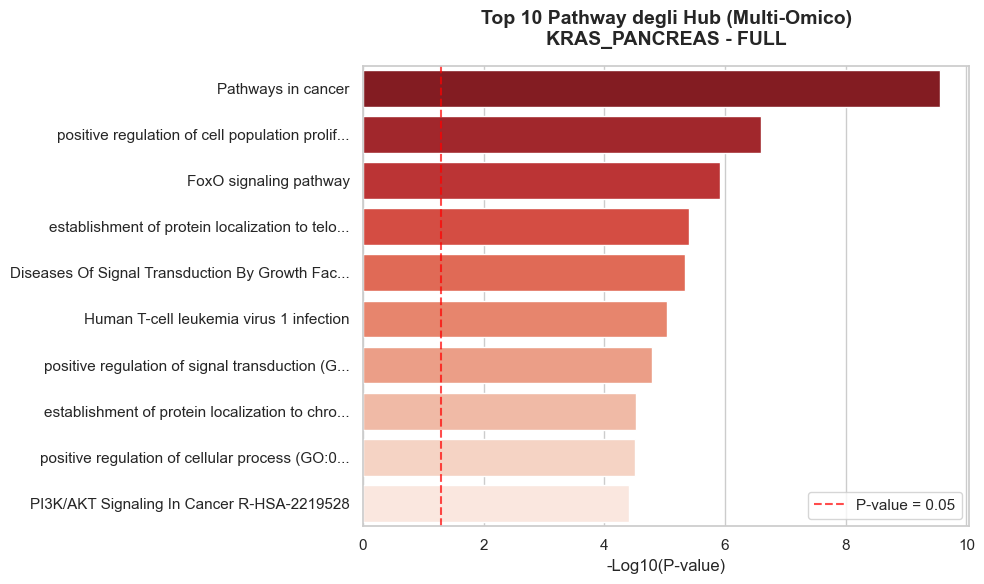

📊 Generazione grafico enrichment per: KRAS_LUNG (FULL)...


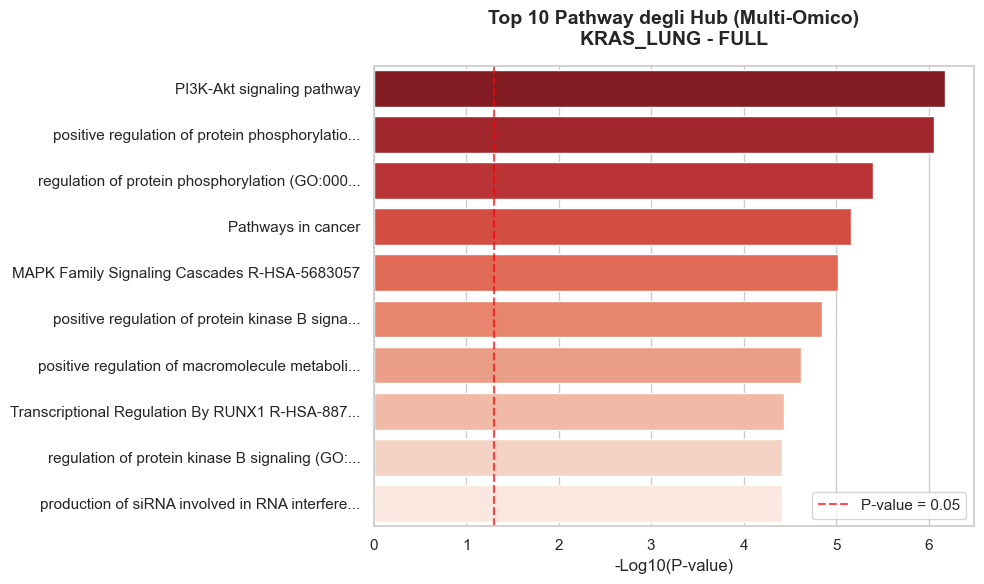

📊 Generazione grafico enrichment per: KRAS_LUNG_LUSC (FULL)...


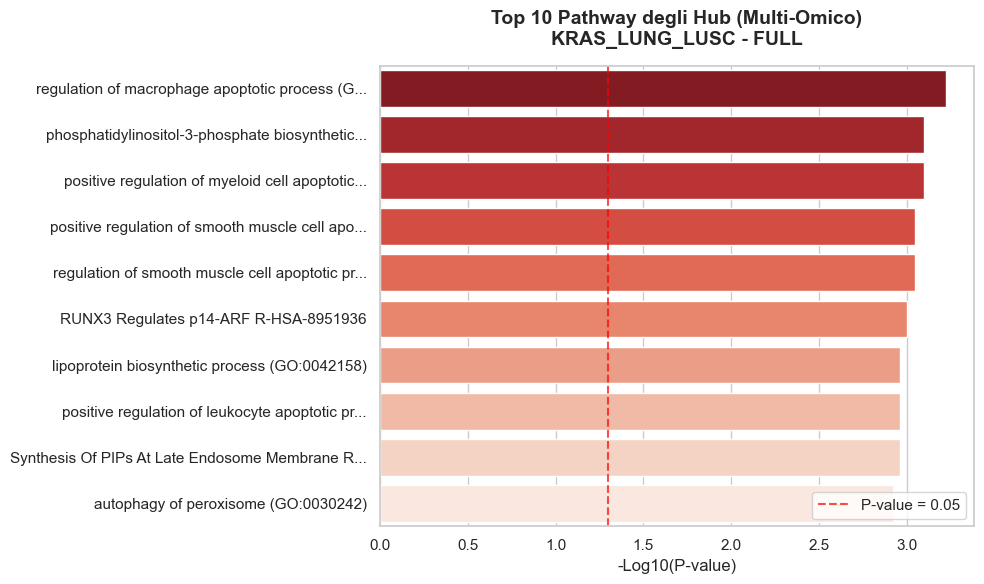

📊 Generazione grafico enrichment per: KRAS_LUNG_LUAD (FULL)...


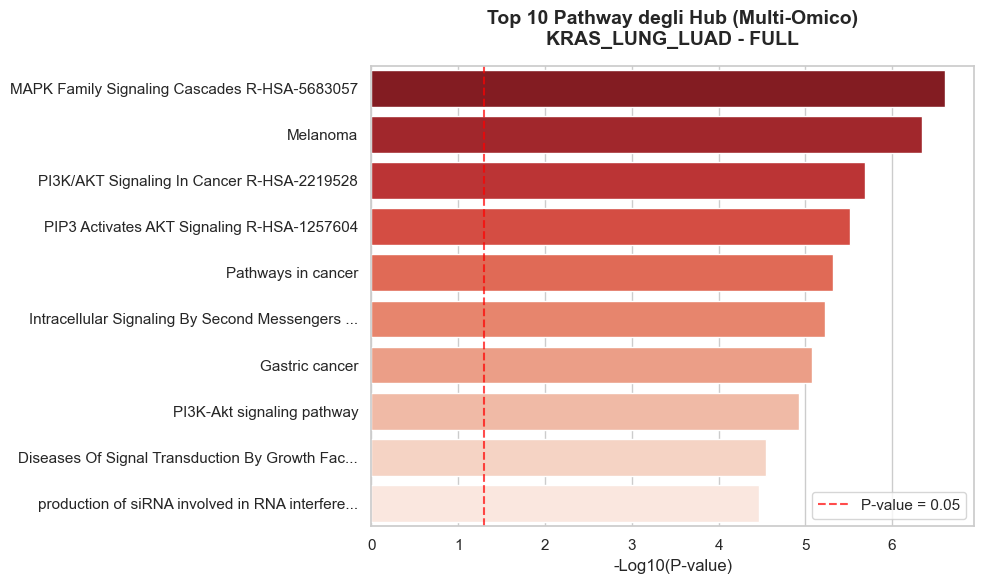

📊 Generazione grafico enrichment per: KRAS_COLON (FULL)...


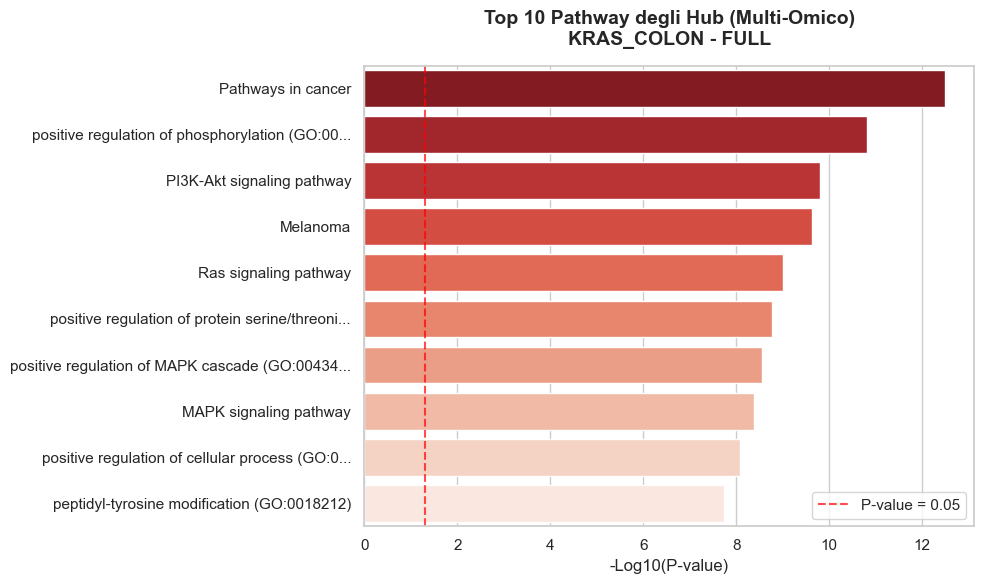

📊 Generazione grafico enrichment per: PANCREAS (FULL)...


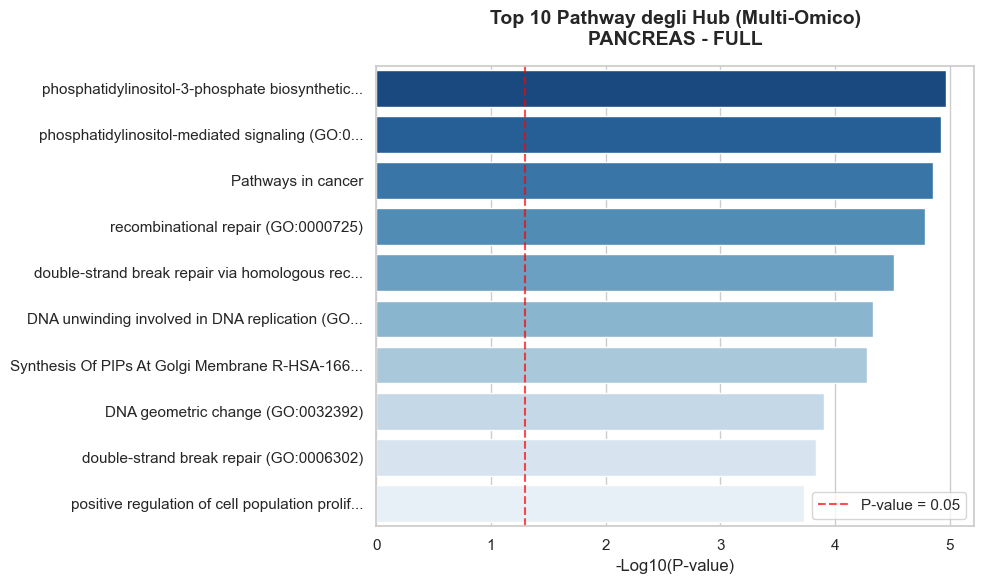

📊 Generazione grafico enrichment per: LUNG (FULL)...


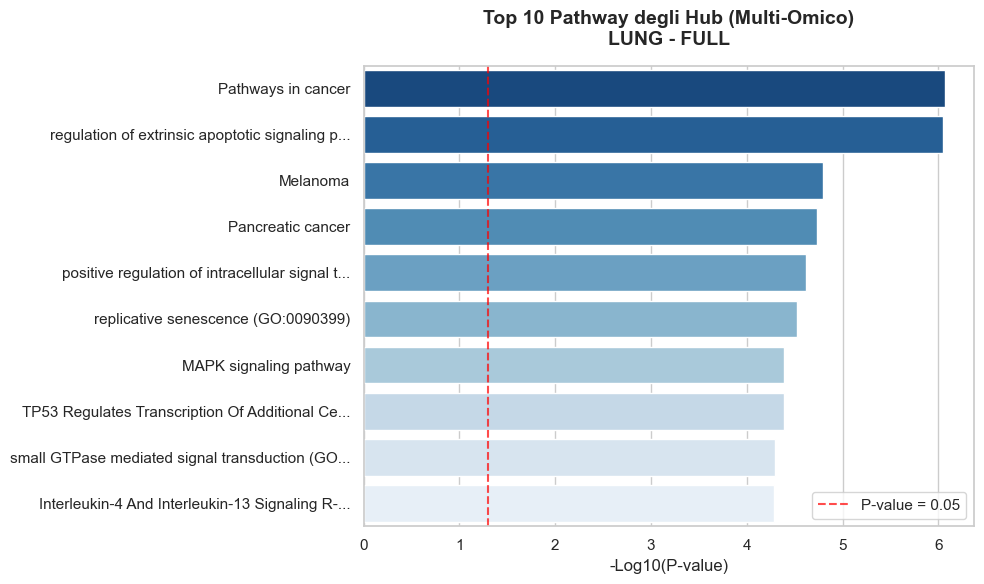

📊 Generazione grafico enrichment per: LUNG_LUSC (FULL)...


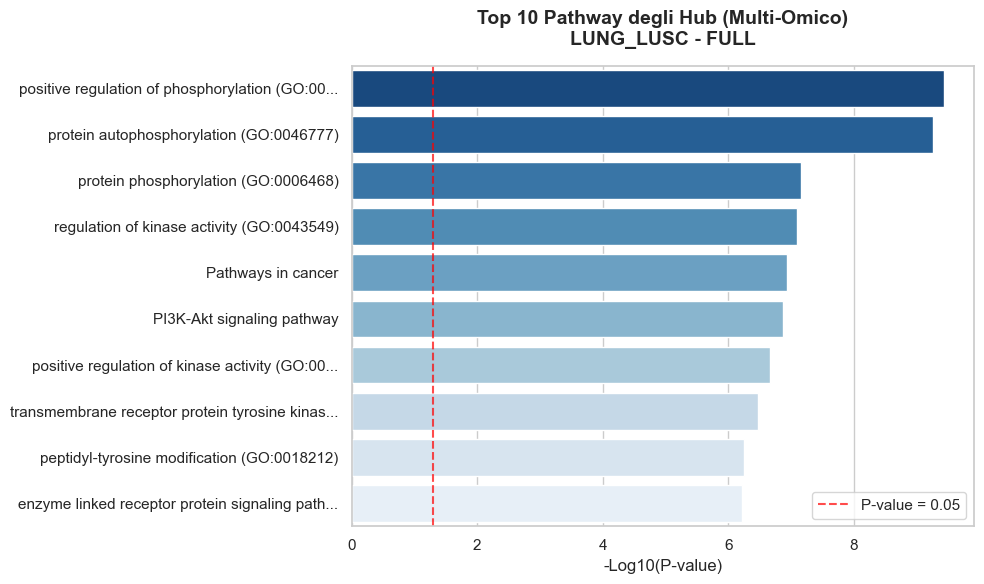

📊 Generazione grafico enrichment per: LUNG_LUAD (FULL)...


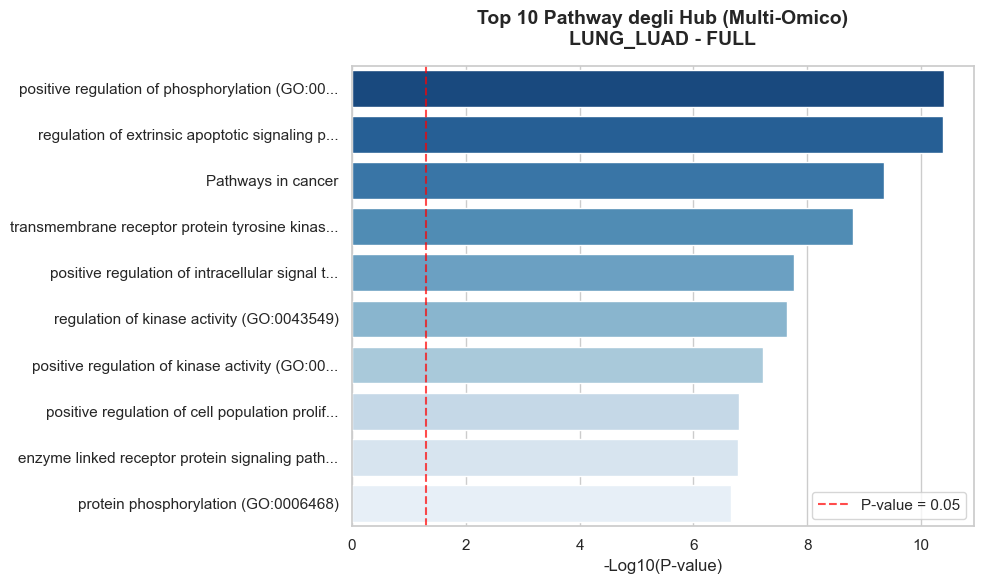

📊 Generazione grafico enrichment per: LUNG_LUAD (FILTERED)...


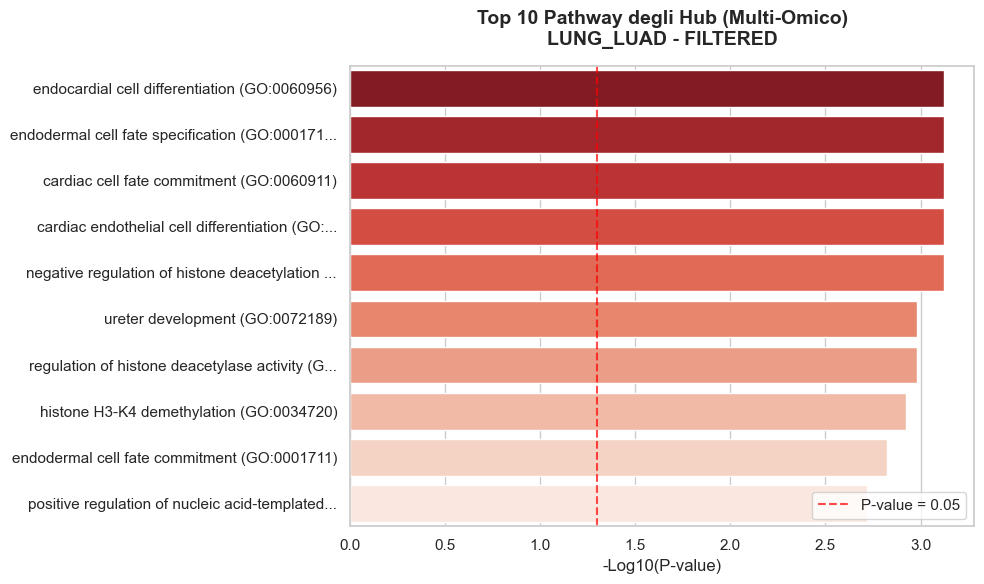

📊 Generazione grafico enrichment per: COLON (FULL)...


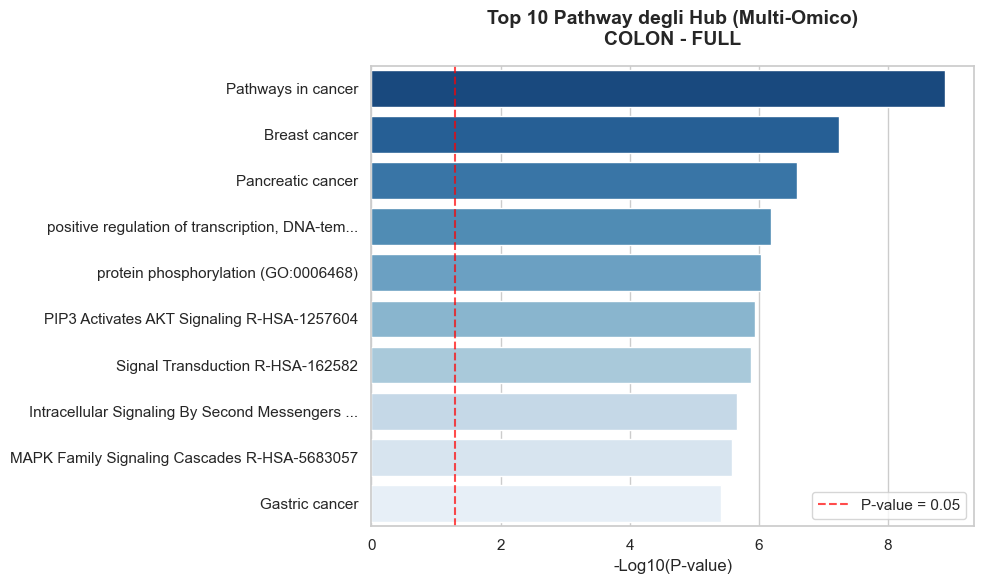

📊 Generazione grafico enrichment per: COLON (FILTERED)...


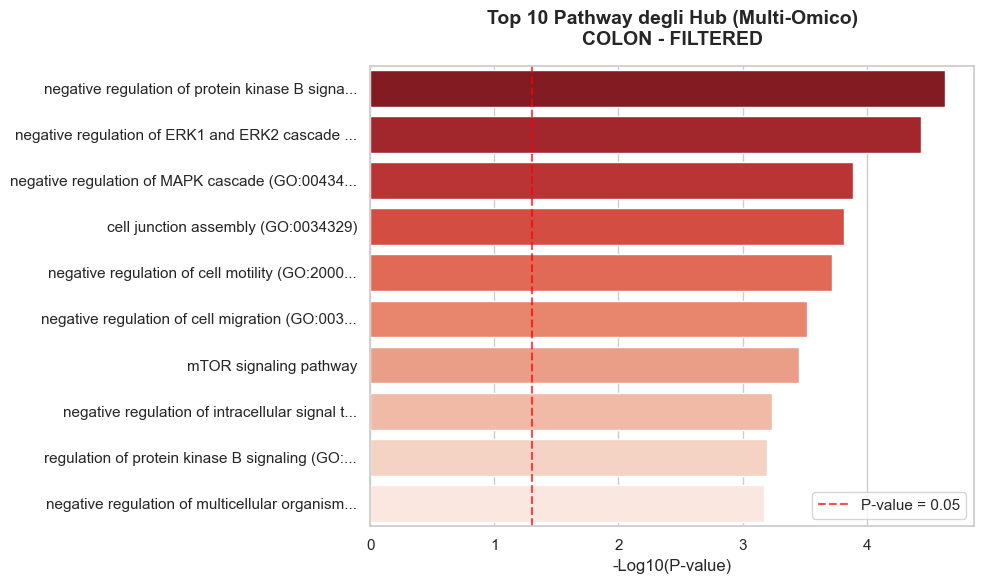


🎉 TUTTI I GRAFICI SONO STATI GENERATI E SALVATI NELLA CARTELLA 'plots'!


In [8]:
# ==========================================
# CELLA 11: VISUALIZZAZIONE GRAFICA DELL'ENRICHMENT DEGLI HUB
# ==========================================

def plot_hub_enrichment(cohort_name, target_gene, is_full=True):
    net_type = "FULL" if is_full else f"FILTERED"

    # 1. Percorsi file e cartelle
    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}"
    enrichment_file = f"{base_dir}/intracluster/enrichment/Enrichment_NetworkHubs_{net_type}_{cohort_name}.tsv"

    plot_dir = f"{base_dir}/plots"
    os.makedirs(plot_dir, exist_ok=True)

    if not os.path.exists(enrichment_file):
        return  # Esce silenziosamente se non ci sono risultati significativi

    df_enr = pd.read_csv(enrichment_file, sep='\t')
    if df_enr.empty:
        return

    print(f"📊 Generazione grafico enrichment per: {cohort_name.upper()} ({net_type})...")

    # 2. Preparazione dati (Top 10 Pathway)
    top_10 = df_enr.sort_values('P-value').head(10).copy()
    top_10['Minus_Log10_Pval'] = -np.log10(top_10['P-value'])
    top_10['Term'] = top_10['Term'].apply(lambda x: (x[:45] + '...') if len(x) > 45 else x)

    # 3. Grafico
    plt.figure(figsize=(10, 6))
    palette_color = "Reds_r" if ("FILTERED" in net_type or "kras_" in cohort_name) else "Blues_r"

    ax = sns.barplot(
        x='Minus_Log10_Pval',
        y='Term',
        data=top_10,
        palette=palette_color,
        hue='Term',
        legend=False
    )

    titolo_grafico = f"Top 10 Pathway degli Hub (Multi-Omico)\n{cohort_name.upper()} - {net_type}"
    plt.title(titolo_grafico, fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('-Log10(P-value)', fontsize=12)
    plt.ylabel('')
    plt.axvline(x=1.3, color='red', linestyle='--', alpha=0.7, label='P-value = 0.05')
    plt.legend(loc='lower right')
    plt.tight_layout()

    # 4. Salvataggio
    out_plot_png = f"{plot_dir}/Barplot_Hub_Enrichment_{net_type}_{cohort_name}.png"
    plt.savefig(out_plot_png, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# ==========================================
# ESECUZIONE AUTOMATICA
# ==========================================
print("\n" + "="*80)
print("🎨 AVVIO GENERAZIONE GRAFICI DI ENRICHMENT HUB")
print("="*80)

list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    if cohort.startswith('kras_'):
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=True)
    else:
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=True)
        plot_hub_enrichment(cohort, TARGET_GENE, is_full=False)

print("\n🎉 TUTTI I GRAFICI SONO STATI GENERATI E SALVATI NELLA CARTELLA 'plots'!")


# ENRICHMENT PER OGNI CLUSTER

In [9]:
# ==========================================
# CELLA 12: ENRICHMENT ANALYSIS DEI CLUSTER INTERI (MULTI-OMICO)
# ==========================================

def run_cluster_enrichment(cohort_name, target_gene, is_full=True, apply_hk=False):
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n--- 🧬 AVVIO ENRICHMENT CLUSTER: {cohort_name.upper()} ({net_type}) ---")

    # 1. Percorsi
    cluster_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/networks"
    enrichment_dir = f"{cluster_dir}/enrichment"
    os.makedirs(enrichment_dir, exist_ok=True)
    cluster_file = f"{cluster_dir}/Cluster_Genes_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(cluster_file):
        print(f"[!] File cluster non trovato: {cluster_file}")
        return

    df_clusters = pd.read_csv(cluster_file, sep='\t', low_memory=False)

    # 2. Auto-discovery database aggiornati
    available_libs = gp.get_library_name(organism='human')
    reactome_versions = sorted([lib for lib in available_libs if 'Reactome' in lib])
    latest_reactome = reactome_versions[-1] if reactome_versions else 'Reactome_2016'
    print(f"[*] Auto-detect Reactome: '{latest_reactome}'")

    databases = [
        'KEGG_2021_Human',
        'GO_Biological_Process_2021',
        'GO_Cellular_Component_2021',
        'GO_Molecular_Function_2021',
        latest_reactome
    ]

    all_results = []
    cluster_ids = df_clusters['Cluster_ID'].unique()

    for c_id in cluster_ids:
        genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()

        # Filtro housekeeping opzionale
        if apply_hk:
            genes = filter_housekeeping(genes)

        if len(genes) < 4:
            print(f"  Cluster {c_id}: saltato ({len(genes)} geni, troppo pochi).")
            continue

        print(f"  Analizzo Cluster {c_id} ({len(genes)} geni)...")

        try:
            enr = gp.enrichr(gene_list=genes, gene_sets=databases, organism='human', outdir=None)
            res_df = enr.results
            sig_res = res_df[res_df['P-value'] < 0.05].copy()

            if not sig_res.empty:
                sig_res['Cluster_ID'] = c_id
                all_results.append(sig_res)

            time.sleep(1)
        except Exception as e:
            print(f"  Errore Cluster {c_id}: {e}")

    # 3. Salvataggio
    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)
        cols = ['Cluster_ID', 'Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Genes']
        final_df = final_df[cols].sort_values(by=['Cluster_ID', 'P-value'], ascending=[True, True])

        out_file_tsv = f"{enrichment_dir}/Enrichment_Clusters_{net_type}_{cohort_name}.tsv"
        final_df.to_csv(out_file_tsv, sep='\t', index=False)
        print(f"✅ Tabella dati salvata in: {out_file_tsv}")

        out_file_txt = f"{enrichment_dir}/Report_Clusters_Top5perDB_{net_type}_{cohort_name}.txt"
        with open(out_file_txt, 'w', encoding='utf-8') as f:
            titolo = f"--- 🏆 TOP 5 PATHWAY/ONTOLOGY PER DATABASE PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
            print(f"\n{titolo}")
            f.write(f"{titolo}\n")

            for c_id in final_df['Cluster_ID'].unique():
                cluster_genes = df_clusters[df_clusters['Cluster_ID'] == c_id]['Gene'].tolist()
                genes_str = ", ".join(cluster_genes)

                sep = "="*80
                head1 = f"🎯 CLUSTER {c_id}  |  DIMENSIONE: {len(cluster_genes)} geni"
                head2 = f"🧬 TUTTI I GENI: {genes_str}"

                print(f"\n{sep}\n{head1}\n{head2}\n{sep}")
                f.write(f"\n{sep}\n{head1}\n{head2}\n{sep}\n")

                cluster_data = final_df[final_df['Cluster_ID'] == c_id]

                for db_label, db_keyword in [('GO', 'GO_'), ('KEGG', 'KEGG_'), ('Reactome', 'Reactome')]:
                    db_top5 = cluster_data[cluster_data['Gene_set'].str.contains(db_keyword, case=False)].head(5)
                    if db_top5.empty:
                        continue
                    db_header = f"  [{db_label}]"
                    print(db_header)
                    f.write(f"\n{db_header}\n")
                    for index, row in db_top5.iterrows():
                        path_title = f"  🔸 [{row['Gene_set']}] {row['Term']}"
                        path_stats = f"     P-value: {row['P-value']:.2e}  |  Overlap: {row['Overlap']}"
                        path_genes = f"     🎯 Geni nel pathway: {row['Genes']}"
                        print(f"{path_title}\n{path_stats}\n{path_genes}")
                        f.write(f"{path_title}\n{path_stats}\n{path_genes}\n")

        print(f"\n📄 REPORT TESTUALE SALVATO IN: {out_file_txt}\n")
    else:
        print("[-] Nessun pathway significativo trovato per questi cluster.\n")


# ==========================================
# ESECUZIONE AUTOMATICA
# ==========================================
# Puoi attivare il filtro housekeeping (True/False)
APPLY_HK_CLUSTERS = False

list_of_cohorts = [name for name in COORTI.keys()]

for cohort in list_of_cohorts:
    if cohort.startswith('kras_'):
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True, apply_hk=APPLY_HK_CLUSTERS)
    else:
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=True, apply_hk=APPLY_HK_CLUSTERS)
        run_cluster_enrichment(cohort, TARGET_GENE, is_full=False, apply_hk=APPLY_HK_CLUSTERS)

print("\n🎉 TUTTE LE ANALISI DI ENRICHMENT DEI CLUSTER SONO STATE COMPLETATE!")



--- 🧬 AVVIO ENRICHMENT CLUSTER: KRAS_PANCREAS (FULL) ---
[*] Auto-detect Reactome: 'Reactome_Pathways_2024'
  Analizzo Cluster 0 (56 geni)...
  Analizzo Cluster 1 (12 geni)...
  Analizzo Cluster 2 (11 geni)...
  Analizzo Cluster 3 (11 geni)...
  Analizzo Cluster 4 (8 geni)...
  Analizzo Cluster 5 (7 geni)...
  Analizzo Cluster 6 (5 geni)...
  Analizzo Cluster 7 (4 geni)...
  Cluster 8: saltato (3 geni, troppo pochi).
  Cluster 9: saltato (3 geni, troppo pochi).
  Cluster 10: saltato (3 geni, troppo pochi).
  Cluster 11: saltato (2 geni, troppo pochi).
  Cluster 12: saltato (2 geni, troppo pochi).
  Cluster 13: saltato (2 geni, troppo pochi).
  Cluster 14: saltato (2 geni, troppo pochi).
  Cluster 15: saltato (2 geni, troppo pochi).
  Cluster 16: saltato (2 geni, troppo pochi).
  Cluster 17: saltato (2 geni, troppo pochi).
✅ Tabella dati salvata in: ./outputs_all/kras_pancreas/networks/enrichment/Enrichment_Clusters_FULL_kras_pancreas.tsv

--- 🏆 TOP 5 PATHWAY/ONTOLOGY PER DATABASE PER 

# ENRICHMENT DEGLI HUB PER OGNI SINGOLO CLUSTER
Analizza specificamente i top Hub locali di ciascuna comunità.

In [10]:
# ==========================================
# CELLA 13: ENRICHMENT HUB SPECIFICI PER OGNI SINGOLO CLUSTER (MULTI-OMICO)
# ==========================================

def enrich_cluster_hubs(cohort_name, target_gene, is_full=True,
                         apply_hk=False, apply_cyto=False, apply_pc=False):
    net_type = "FULL" if is_full else f"FILTERED"
    print(f"\n" + "="*80)
    print(f"🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: {cohort_name.upper()} ({net_type})")
    print("="*80)

    base_dir = f"{OUTPUT_BASE_DIR}/{cohort_name}/intracluster"
    enrichment_dir = f"{base_dir}/enrichment"
    os.makedirs(enrichment_dir, exist_ok=True)
    centrality_file = f"{base_dir}/Intracluster_Centrality_{net_type}_{cohort_name}.tsv"

    if not os.path.exists(centrality_file):
        print(f"[!] File centralità non trovato per {cohort_name} ({net_type}). Esegui prima la Cella 9.")
        return

    df_centrality = pd.read_csv(centrality_file, sep='\t')
    databases = ['KEGG_2021_Human', 'GO_Biological_Process_2021', 'Reactome_2022']

    out_txt = f"{enrichment_dir}/Report_ClusterHubs_Top5perDB_{net_type}_{cohort_name}.txt"
    with open(out_txt, 'w', encoding='utf-8') as f:
        titolo = f"--- 🏆 TOP 5 PATHWAY PER DATABASE — HUB LOCALI PER OGNI CLUSTER ({cohort_name.upper()} - {net_type}) ---"
        f.write(f"{titolo}\n\n")

        for c_id in df_centrality['Cluster_ID'].unique():
            cluster_df = df_centrality[df_centrality['Cluster_ID'] == c_id]
            top_hubs = cluster_df.head(5)['Gene'].tolist()

            # Filtri opzionali sugli hub locali
            if apply_hk:
                top_hubs = filter_housekeeping(top_hubs)
            if apply_cyto:
                top_hubs = filter_cytoband(top_hubs)
            if apply_pc:
                top_hubs = filter_partition_coefficient(top_hubs, cohort_name, pc_threshold=0.3)

            f.write(f"{'='*80}\n")
            f.write(f"🎯 CLUSTER {c_id}  |  TOP HUB ANALIZZATI: {len(top_hubs)}\n")
            f.write(f"🧬 GENI HUB: {', '.join(top_hubs)}\n")
            f.write(f"{'='*80}\n\n")

            if len(top_hubs) < 2:
                f.write("[-] Troppi pochi hub per un enrichment (dopo filtraggio).\n\n")
                print(f"  Cluster {c_id}: Saltato ({len(top_hubs)} hub rimasti dopo filtraggio).")
                continue

            print(f"  Analizzo Hub del Cluster {c_id} ({len(top_hubs)} hub)...")
            try:
                enr = gp.enrichr(gene_list=top_hubs, gene_sets=databases, organism='human', outdir=None)
                sig_res = enr.results[enr.results['P-value'] < 0.05].copy()
                time.sleep(1)
            except Exception as e:
                f.write(f"[-] Errore Enrichr per questo cluster: {e}\n\n")
                continue

            if not sig_res.empty:
                sig_res = sig_res.sort_values(by=['P-value'], ascending=True)
                for db_label, db_keyword in [('GO', 'GO_'), ('KEGG', 'KEGG_'), ('Reactome', 'Reactome')]:
                    db_top5 = sig_res[sig_res['Gene_set'].str.contains(db_keyword, case=False)].head(5)
                    if db_top5.empty:
                        continue
                    f.write(f"  [{db_label}]\n")
                    for index, row in db_top5.iterrows():
                        f.write(f"  🔸 [{row['Gene_set']}] {row['Term']}\n")
                        f.write(f"     - P-value: {row['P-value']:.2e} | Overlap: {row['Overlap']}\n")
                        f.write(f"     - Geni nel pathway: {row['Genes']}\n\n")
            else:
                f.write("[-] Nessun pathway significativo trovato.\n\n")

    print(f"✅ Report salvato: {out_txt}")


# ==========================================
# ESECUZIONE AUTOMATICA
# ==========================================
# Stessi flag globali usati per l'enrichment degli hub globali
for cohort in COORTI.keys():
    enrich_cluster_hubs(
        cohort, TARGET_GENE, is_full=True,
        apply_hk=APPLY_HOUSEKEEPING_FILTER,
        apply_cyto=APPLY_CYTOBAND_FILTER,
        apply_pc=APPLY_PARTITION_COEFFICIENT_FILTER
    )
    if not cohort.startswith('kras_'):
        enrich_cluster_hubs(
            cohort, TARGET_GENE, is_full=False,
            apply_hk=APPLY_HOUSEKEEPING_FILTER,
            apply_cyto=APPLY_CYTOBAND_FILTER,
            apply_pc=APPLY_PARTITION_COEFFICIENT_FILTER
        )

print("\n🎉 ENRICHMENT HUB DEI CLUSTER COMPLETATO!")



🌟 ENRICHMENT HUB DEI SINGOLI CLUSTER: KRAS_PANCREAS (FULL)
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 2 geni altamente polarizzati (PC < 0.3).
  Analizzo Hub del Cluster 0 (3 hub)...
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 3 geni altamente polarizzati (PC < 0.3).
  Analizzo Hub del Cluster 1 (2 hub)...
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 1 geni altamente polarizzati (PC < 0.3).
  Analizzo Hub del Cluster 2 (4 hub)...
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 4 geni altamente polarizzati (PC < 0.3).
  Cluster 3: Saltato (1 hub rimasti dopo filtraggio).
  [Filtro HK] Rimossi 1 geni housekeeping.
  [Filtro PC] Rimossi 0 geni altamente polarizzati (PC < 0.3).
  Analizzo Hub del Cluster 4 (4 hub)...
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filtro PC] Rimossi 3 geni altamente polarizzati (PC < 0.3).
  Analizzo Hub del Cluster 5 (2 hub)...
  [Filtro HK] Rimossi 0 geni housekeeping.
  [Filt